In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_excel('Enhanced_pizza_sell_data_2024-25.xlsx')
df.shape

(1004, 25)

In [4]:
df.head()

,Order ID,Restaurant Name,Location,Order Time,Delivery Time,Delivery Duration (min),Pizza Size,Pizza Type,Toppings Count,Distance (km),Traffic Level,Payment Method,Is Peak Hour,Is Weekend,Delivery Efficiency (min/km),Topping Density,Order Month,Payment Category,Estimated Duration (min),Delay (min),Is Delayed,Pizza Complexity,Traffic Impact,Order Hour,Restaurant Avg Time
0,ORD001,Domino's,"New York, NY",2024-01-05 18:30:00,2024-01-05 18:45:00,15,Medium,Veg,3,2.5,Medium,Card,True,False,6.000000,1.200000,January,Online,6.0,9.0,False,6,2,18,30.259434
1,ORD002,Papa John's,"Los Angeles, CA",2024-02-14 20:00:00,2024-02-14 20:25:00,25,Large,Non-Veg,4,5.0,High,Wallet,True,False,5.000000,0.800000,February,Online,12.0,13.0,False,12,3,20,28.186275
2,ORD003,Little Caesars,"Chicago, IL",2024-03-21 12:15:00,2024-03-21 12:35:00,20,Small,Vegan,2,3.0,Low,UPI,False,False,6.666667,0.666667,March,Online,7.2,12.8,False,2,1,12,28.844221
3,ORD004,Pizza Hut,"Miami, FL",2024-04-10 19:45:00,2024-04-10 20:10:00,25,XL,Cheese Burst,5,4.5,Medium,Cash,True,False,5.555556,1.111111,April,Offline,10.8,14.2,False,20,2,19,29.948454
4,ORD005,Marco's Pizza,"Dallas, TX",2024-05-05 13:00:00,2024-05-05 13:20:00,20,Medium,Non-Veg,3,2.0,High,Card,False,True,10.000000,1.500000,May,Online,4.8,15.2,False,6,3,13,30.286458


In [5]:
print(df['Restaurant Name'].unique())
print(df.isnull().sum().sum())
print(df['Order ID'].duplicated().sum())

["Domino's" "Papa John's" 'Little Caesars' 'Pizza Hut' "Marco's Pizza"]
0
0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004 entries, 0 to 1003
Data columns (total 25 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Order ID                      1004 non-null   object        
 1   Restaurant Name               1004 non-null   object        
 2   Location                      1004 non-null   object        
 3   Order Time                    1004 non-null   datetime64[ns]
 4   Delivery Time                 1004 non-null   datetime64[ns]
 5   Delivery Duration (min)       1004 non-null   int64         
 6   Pizza Size                    1004 non-null   object        
 7   Pizza Type                    1004 non-null   object        
 8   Toppings Count                1004 non-null   int64         
 9   Distance (km)                 1004 non-null   float64       
 10  Traffic Level                 1004 non-null   object        
 11  Payment Method                

In [7]:
df.isnull().sum()


Order ID                        0
Restaurant Name                 0
Location                        0
Order Time                      0
Delivery Time                   0
Delivery Duration (min)         0
Pizza Size                      0
Pizza Type                      0
Toppings Count                  0
Distance (km)                   0
Traffic Level                   0
Payment Method                  0
Is Peak Hour                    0
Is Weekend                      0
Delivery Efficiency (min/km)    0
Topping Density                 0
Order Month                     0
Payment Category                0
Estimated Duration (min)        0
Delay (min)                     0
Is Delayed                      0
Pizza Complexity                0
Traffic Impact                  0
Order Hour                      0
Restaurant Avg Time             0
dtype: int64

In [8]:
#Overall delay rate
delay_rate = df ['Is Delayed'].mean() * 100
print(f"Overall delay rate: {delay_rate:.1f}%")
df['Is Delayed'].value_counts()

Overall delay rate: 21.5%


Is Delayed
False    788
True     216
Name: count, dtype: int64

In [9]:
#Delay by Traffic level
traffic_delay = df.groupby('Traffic Level').agg(
    avg_delay=('Delay (min)', 'mean'),
    delay_rate=('Is Delayed', 'mean'),
    orders=('Order ID', 'count')
).sort_values('avg_delay', ascending=False)
traffic_delay['delay_rate'] = (traffic_delay['delay_rate']*100).round(1)
traffic_delay

,avg_delay,delay_rate,orders
Traffic Level,,,
High,19.159146,50.0,328
Medium,17.863819,11.8,398
Low,15.464173,1.8,278


In [10]:
# Delay by Peak Hour
peak_delay = df.groupby('Is Peak Hour').agg(
    avg_delay=('Delay (min)', 'mean'),
    delay_rate=('Is Delayed', 'mean'),
    orders=('Order ID', 'count')
)
peak_delay['delay_rate'] = (peak_delay['delay_rate']*100).round(1)
peak_delay


,avg_delay,delay_rate,orders
Is Peak Hour,,,
False,13.482182,3.6,55
True,17.862508,22.6,949


In [11]:
# Delay by Restaurant
restaurant_delay = df.groupby('Restaurant Name').agg(
    avg_delay=('Delay (min)', 'mean'),
    delay_rate=('Is Delayed', 'mean'),
    orders=('Order ID', 'count')
).sort_values('avg_delay', ascending=False)
restaurant_delay['delay_rate'] = (restaurant_delay['delay_rate']*100).round(1)
restaurant_delay

,avg_delay,delay_rate,orders
Restaurant Name,,,
Marco's Pizza,18.435077,19.5,195
Pizza Hut,18.241436,22.6,195
Papa John's,17.887451,14.2,204
Domino's,16.988057,28.9,211
Little Caesars,16.621106,22.1,199


In [12]:
# Correlation of numeric factors with Delay
numeric_cols = ['Distance (km)', 'Toppings Count', 'Pizza Complexity', 'Traffic Impact', 'Delivery Efficiency (min/km)', 'Delay (min)']
corr = df[numeric_cols].corr()['Delay (min)'].sort_values(ascending=False)
corr

Delay (min)                     1.000000
Distance (km)                   0.604837
Traffic Impact                  0.357951
Toppings Count                  0.140368
Pizza Complexity                0.107086
Delivery Efficiency (min/km)    0.031197
Name: Delay (min), dtype: float64

C:\Users\Admin\AppData\Local\Temp\ipykernel_20232\3373860019.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Traffic Level', y='Delay (min)', order=['Low','Medium','High'], ax=axes[0], palette='Oranges')
C:\Users\Admin\AppData\Local\Temp\ipykernel_20232\3373860019.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Is Peak Hour', y='Delay (min)', ax=axes[1], palette='Blues')


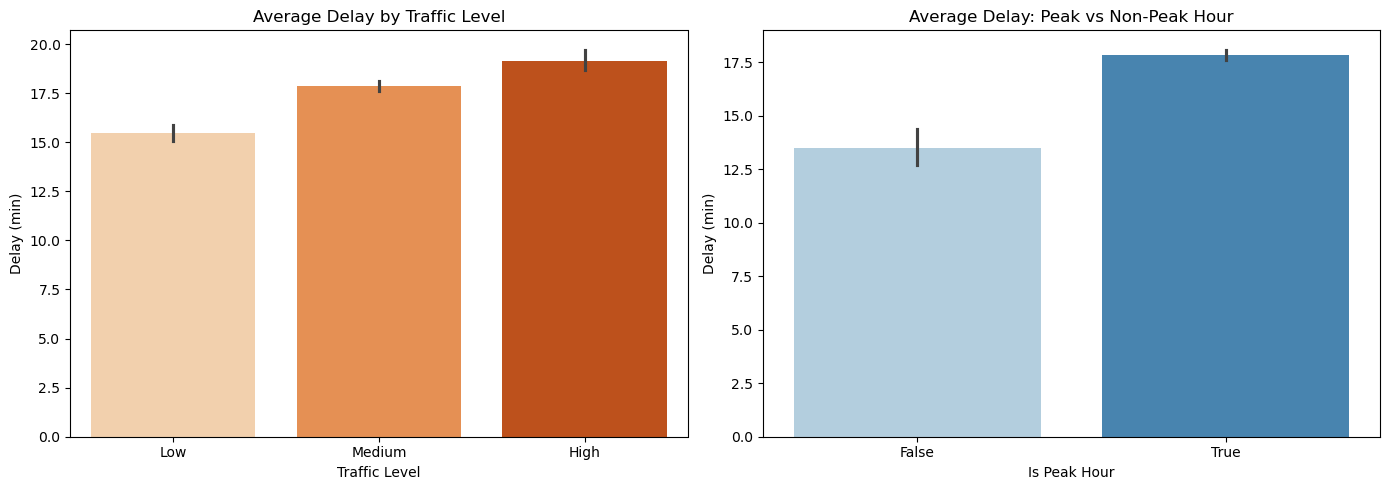

In [13]:
# Visualize: Delay by Traffic Level and Peak Hour
fig, axes = plt.subplots(1,2, figsize=(14, 5))

sns.barplot(data=df, x='Traffic Level', y='Delay (min)', order=['Low','Medium','High'], ax=axes[0], palette='Oranges')
axes[0].set_title('Average Delay by Traffic Level')

sns.barplot(data=df, x='Is Peak Hour', y='Delay (min)', ax=axes[1], palette='Blues')
axes[1].set_title('Average Delay: Peak vs Non-Peak Hour')

plt.tight_layout()
plt.show()

In [14]:
for r in ["Domino's", "Pizza Hut"]:
    sub = df[(df['Restaurant Name']==r) & (df['Is Delayed']==True)]
    print(f"{r}: {len(sub)} delayed orders, avg delay = {sub['Delay (min)'].mean():.1f} min, median = {sub['Delay (min)'].median():.1f} min")
    print(f"  % of delays under 22min: {(sub['Delay (min)']<22).mean()*100:.1f}%")
    print()

Domino's: 61 delayed orders, avg delay = 24.0 min, median = 23.4 min
  % of delays under 22min: 27.9%

Pizza Hut: 44 delayed orders, avg delay = 21.9 min, median = 21.4 min
  % of delays under 22min: 50.0%



In [15]:
from sqlalchemy import create_engine

# Step 1: Connect to PostgreSQL
# Replace placeholders with your actual details
username = "postgres"      # default user
password = "YourPassword" # the password you set during installation
host = "localhost"         # if running locally
port = "5432"              # default PostgreSQL port
database = "pizza_sell"    # the database you created in pgAdmin

engine = create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")

# Step 2: Load DataFrame into PostgreSQL
table_name = "pizza_orders"   # choose any table name
df.to_sql(table_name, engine, if_exists="replace", index=False)

print(f"Data successfully loaded into table '{table_name}' in database '{database}'.")

Data successfully loaded into table 'pizza_orders' in database 'pizza_sell'.
